# Business Case:-
* **Create a predictive model  using machine learning techniques to predict the various classes of skin disease.** 

In [1]:
## importing libraries
import numpy as np                  # importing numpy for mathematical/numerical analysis
import pandas as pd                 # importing pandas for analyzing, manipulation or claeaning data
import seaborn as sns               # importing seaborn for visualize the data
import matplotlib.pyplot as plt     # importing matplotlib for visualize and ploting the statistical data
import warnings                     # importing warnings to ignore any type of warnings
warnings.filterwarnings('ignore')   # filter warnings to ignore

In [2]:
## reading a csv file
data = pd.read_csv("dataset_35_dermatology (1).csv")
pd.set_option('display.max_columns',None)   ## to show all the columns in the display
data

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,0,2,2,0,0,3,3,0,0,0,0,0,0,0,3,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,0,2,0,0,0,3,2,0,0,0,0,0,0,0,3,0,2,0,1,0,0,2,3,50,3


## Domain Analysis

This database contains **34 attributes**, 33 of which are linear valued and one of them is nominal.<br>

* The target column is **class** in which we have 6 different classes:<br>
    1: ****Psoriasis**** :- Psoriasis is a chronic autoimmune condition where the immune system causes skin cells to grow too quickly, leading to a buildup of cells on the skin's surface.<br>
  ***Treatment*** :- Aims to slow skin cell growth and reduce inflammation. Treatments include topical corticosteroids, light therapy (phototherapy), and systemic medications (oral or injectable) for severe cases.<br>


    2: **Seboreic Dermatitis** :- This is a common, chronic type of dermatitis that affects oily areas of the body.and their sysmptoms are Causes greasy, yellowish or reddish scaling on the scalp (dandruff), face (especially around the eyebrows and nose), ears, and upper chest. It can be itchy but is generally less inflamed than psoriasis.<br>
  ***Treatment*** :- Managed with medicated shampoos, creams, and ointments containing agents like ketoconazole (antifungal), coal tar, or mild corticosteroids.<br>

    3: **Lichen Planus** :- Lichen planus is an inflammatory condition that can affect the skin, hair, nails, and mucous membranes (e.g., in the mouth) and the exact cause is often unknown, but it is believed to be an autoimmune response.<br>
  ***Treatment***:- Aims to relieve symptoms, often using topical or oral corticosteroids, antihistamines for itching, and sometimes light therapy.<br>
  
    4: **Pityriasis Rosea** :- Pityriasis rosea is a common, benign, self-limiting skin rash that typically resolves on its own.It often starts with a single, larger, oval-shaped scaly patch called a "herald patch," followed days or weeks later by a widespread rash of smaller, pink or red oval patches, often in a "Christmas tree" pattern on the back. The rash is usually itchy.<br>
  ***Treatment*** :-  Usually no treatment is needed as it clears up within several weeks to months. Symptom relief can be achieved with anti-itch creams or oral antihistamines.<br>
  
    5: **Cronic Dermatitis** :- "Dermatitis" is a general term for skin inflammation, and "chronic" means it is long-lasting (over 3 months). This category encompasses persistent cases of conditions like atopic dermatitis (eczema), contact dermatitis, or stasis dermatitis.<br>
  ***Treatment*** :- Management involves identifying and avoiding triggers, consistent use of moisturizers, and prescription topical or oral medications (e.g., corticosteroids, calcineurin inhibitors) to control inflammation and itching. <br>
  
    6: **Pityriasis Rubra Pilaris**:- PRP is a rare, chronic inflammatory disorder of unknown cause and key features include small, reddish-orange follicular papules that merge into patches, thick yellow-orange skin on the palms and soles (palmoplantar keratoderma). The rash can be itchy.<br>
  ***Treatment***:- Difficult to treat, with the goal of symptom relief. Treatments include emollients, oral retinoids (e.g., acitretin), methotrexate, or newer biologic drugs, as topical steroids often provide only minimal benefit. Classic adult cases may resolve spontaneously within three years, but other forms are persistent.<br>


**Family history:**<br>
   * 1: if any of these diseases has been observed in the family<br>
   * 0: otherwise<br>


**Age**<br>
    It indicates the age of the patients.<br>


**Other Features**<br>
   * 0 indicates that the feature was not present<br>
   * 3 indicates the largest amount possible<br>
   * 1 and 2 indicate the relative intermediate values.<br>


### Basic Checks

In [3]:
data.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3


In [4]:
data.tail()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
361,2,1,1,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,0,2,2,0,0,3,3,0,0,0,0,0,0,0,3,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,0,2,0,0,0,3,2,0,0,0,0,0,0,0,3,0,2,0,1,0,0,2,3,50,3
365,3,2,2,0,0,0,0,0,3,3,0,0,0,1,0,0,2,0,2,3,2,3,0,2,0,2,0,0,0,0,0,3,0,35,1


In [5]:
data.dtypes

erythema                                     int64
scaling                                      int64
definite_borders                             int64
itching                                      int64
koebner_phenomenon                           int64
polygonal_papules                            int64
follicular_papules                           int64
oral_mucosal_involvement                     int64
knee_and_elbow_involvement                   int64
scalp_involvement                            int64
family_history                               int64
melanin_incontinence                         int64
eosinophils_in_the_infiltrate                int64
PNL_infiltrate                               int64
fibrosis_of_the_papillary_dermis             int64
exocytosis                                   int64
acanthosis                                   int64
hyperkeratosis                               int64
parakeratosis                                int64
clubbing_of_the_rete_ridges    

#### Insights
* As we can see that each columns are in integer datatypes except **Age**, So we need to change the datatypes of age.

In [6]:
data.columns

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [8]:
## values counts in class
data['class'].value_counts()

class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64

In [9]:
## statistical Analysis for all numeric column
data.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,0.125683,0.404372,0.139344,0.546448,0.336066,1.368852,1.956284,0.527322,1.289617,0.663934,0.991803,0.633880,0.295082,0.363388,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,0.331946,0.869818,0.411790,0.815451,0.853139,1.104418,0.712512,0.757116,0.917562,1.056829,1.162161,1.034924,0.670578,0.759721,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


## Exploratory Data Analysis

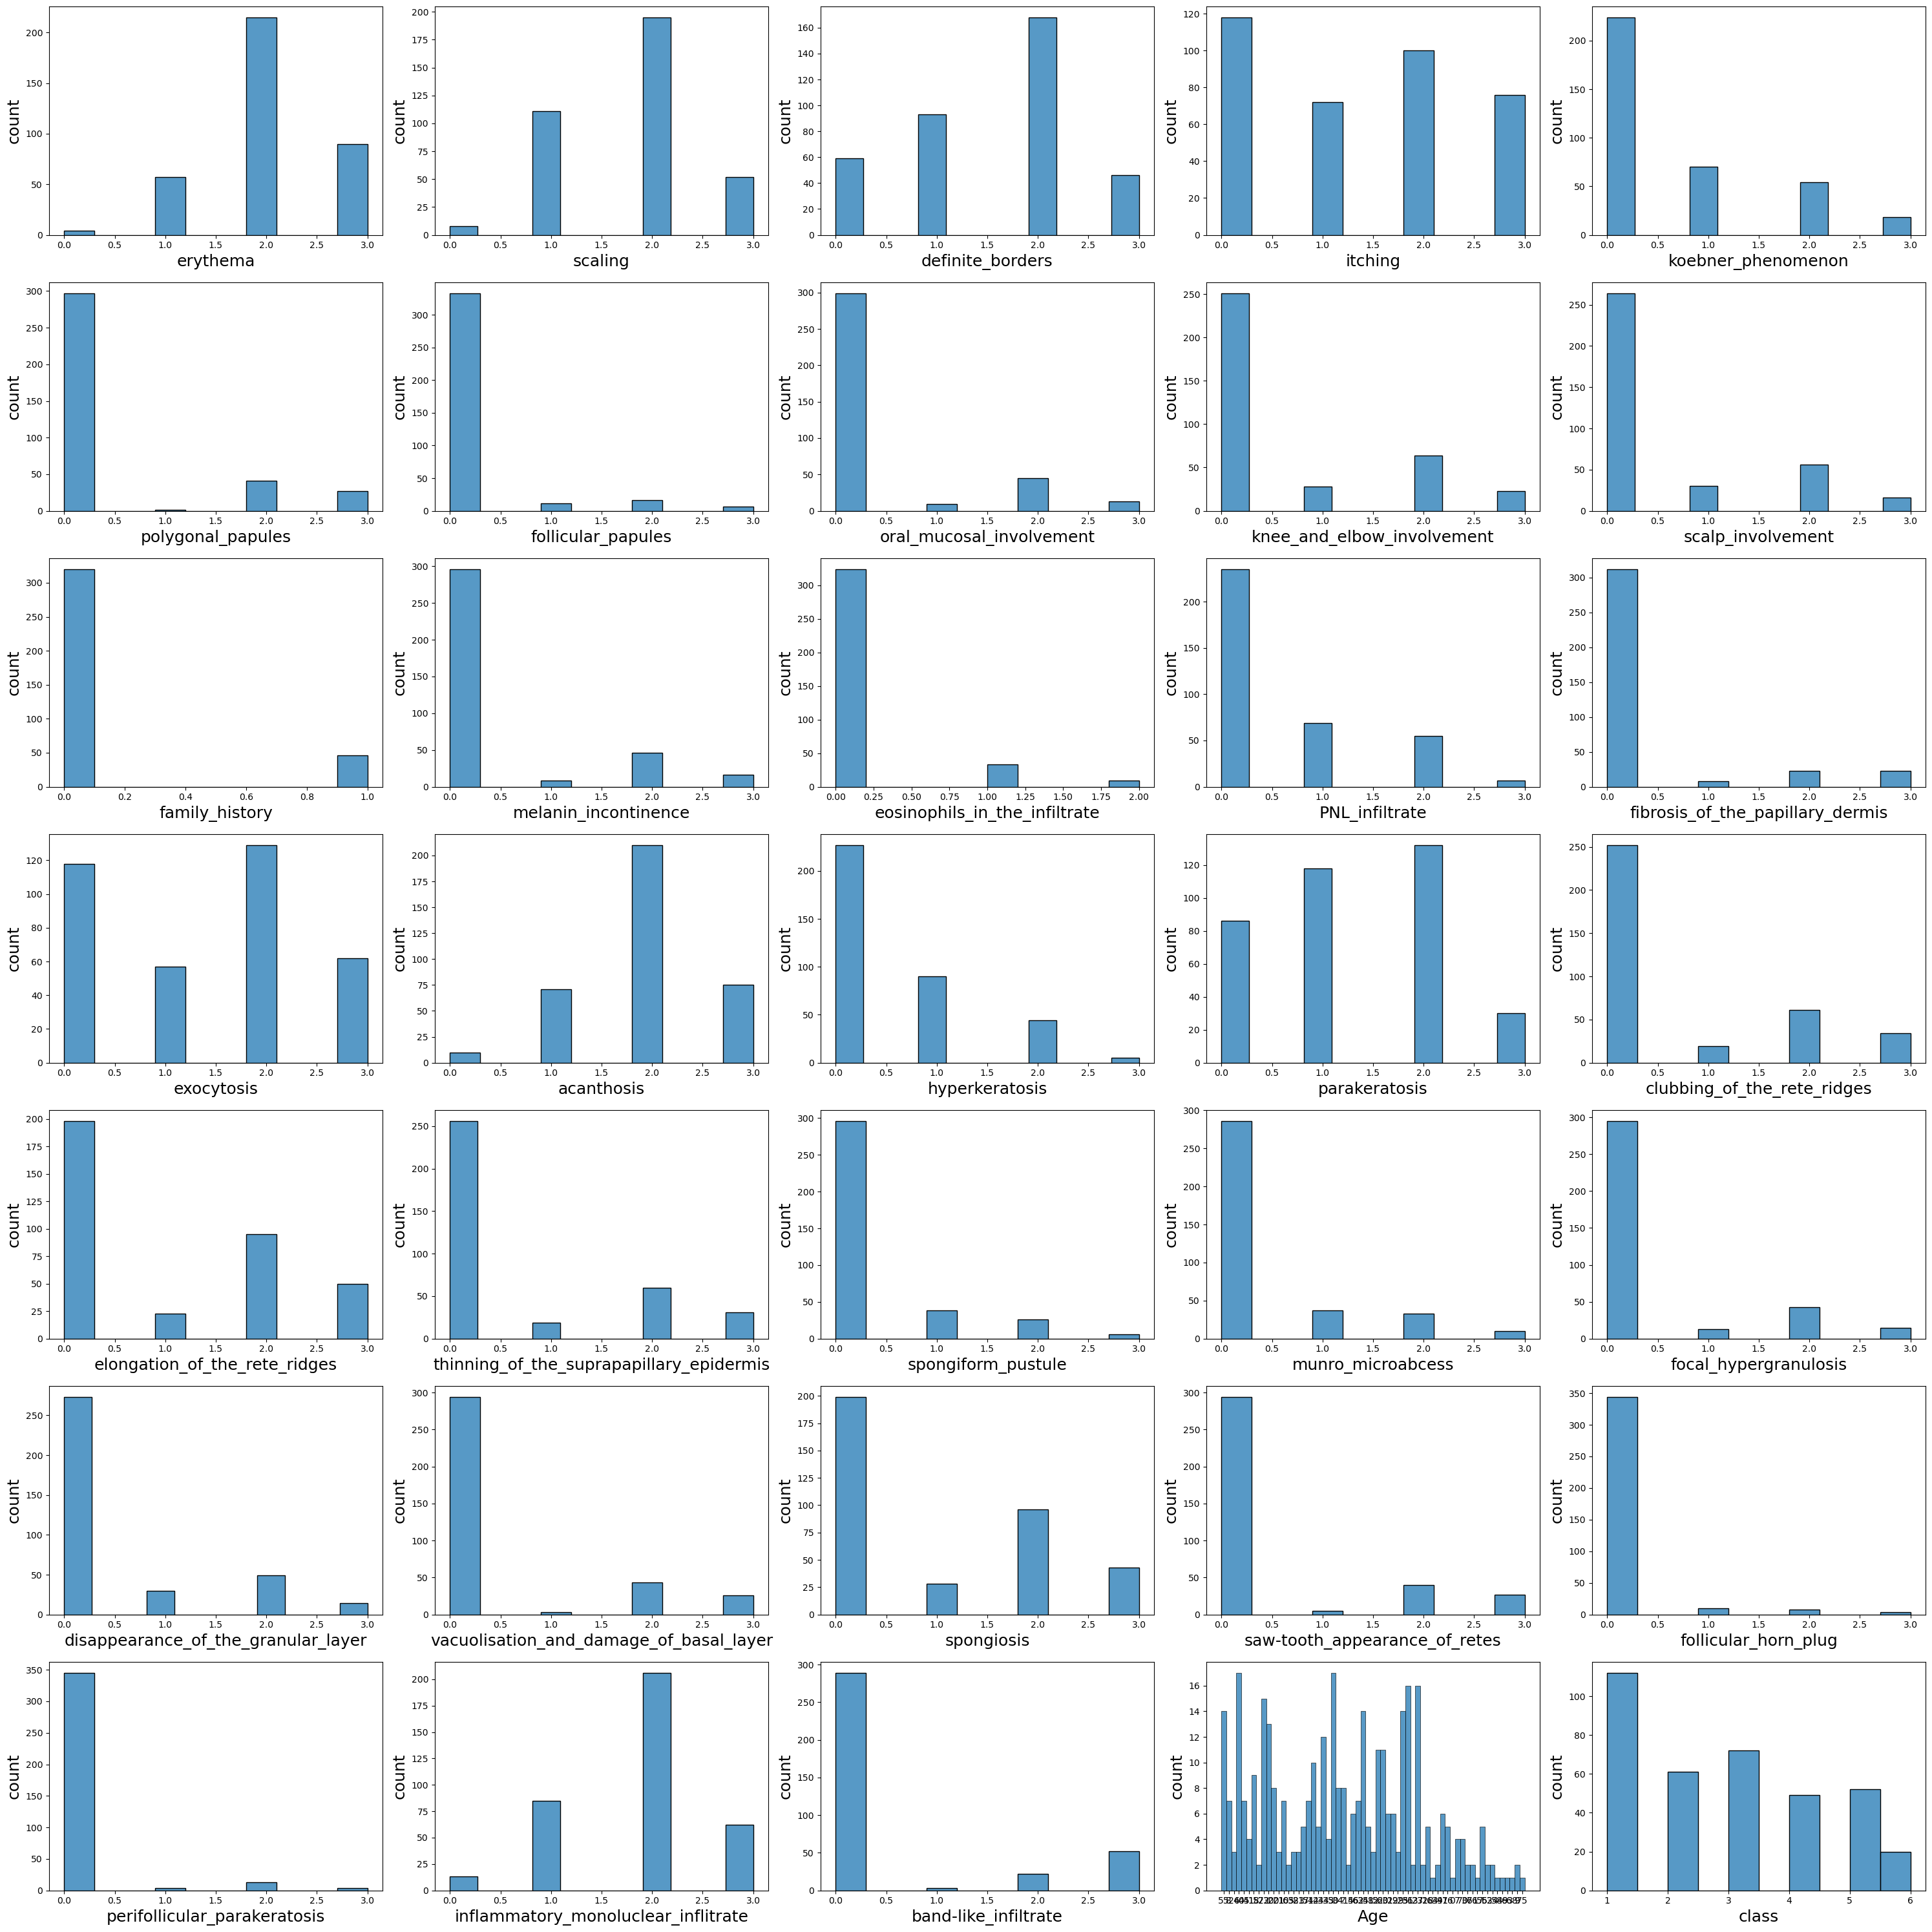

In [10]:
## Ploting the each column 
plt.figure(figsize=(30,30))              ## To fixed the canvas size
plotnumber = 1                           ## Initialize the plotnumber
for i in data.columns:                   ## Using foor loop to visualize the each column
    plt.subplot(7,5,plotnumber)          ## assign a plotnumber for each columns
    sns.histplot(data[i])                ## using histplot to visualize
    plt.xlabel(i,fontsize=18)            ## change the font size of x label
    plt.ylabel('count',fontsize=18)      ## change the font size of y label
    plotnumber += 1                      ## increament the plot number by one
plt.tight_layout()                       ## using the tight layout to adjust space and don't overlap the  figure
plt.show()                               ## to show the figure

## Insights:-

* Most patients showing erythema, scaling, well-defined borders,parakeratosis, acanthosis, and inflammatory mononuclear infiltrates fall into the **relative intermediate group**.
* Itching severity indicates that:<br>
    * Many patients report **no itching**, <br>   
    * A considerable number fall into the **intermediate category**,<br>    
    * Approximately **80 patients** exhibit a high likelihood of itching.<br>
* In most of the features like koebner_phenomenon,polygonal_papules,folicular_papules,polygonal_papules,oral_mucosal_involvement, knee_and_elbow_involvement,scalp_involvement,melanin_incontinence,eosinophils_in_the_infiltrate etc most of the patient having **no problem.**
* Over **80% of patients** report no family history of skin disease.
* In class most of the patient having **no problem** and another class has almost similar patients.

<Axes: xlabel='class', ylabel='count'>

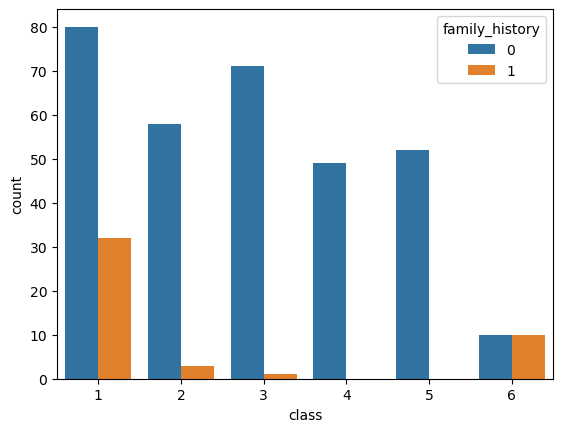

In [11]:
## viualizing class vs family history 
sns.countplot(x=data['class'],hue='family_history',data=data)

### Insights:-

* Most of the Skin Disease having no family history.
* People with **pityriasis rosea**(4) and **chronic dermatitis**(5) usually have no family history of skin problems.
* **Seboreic dermatitis**(2), **lichen planus**(3) are having less chances of skin diseases in family history.
* **Psoriasis**(1) is more likely to have a family connection compared to other skin diseases.
* For **pityriasis rubra pilaris**(6), there is an equal chance of having or not having a family history of skin disease.

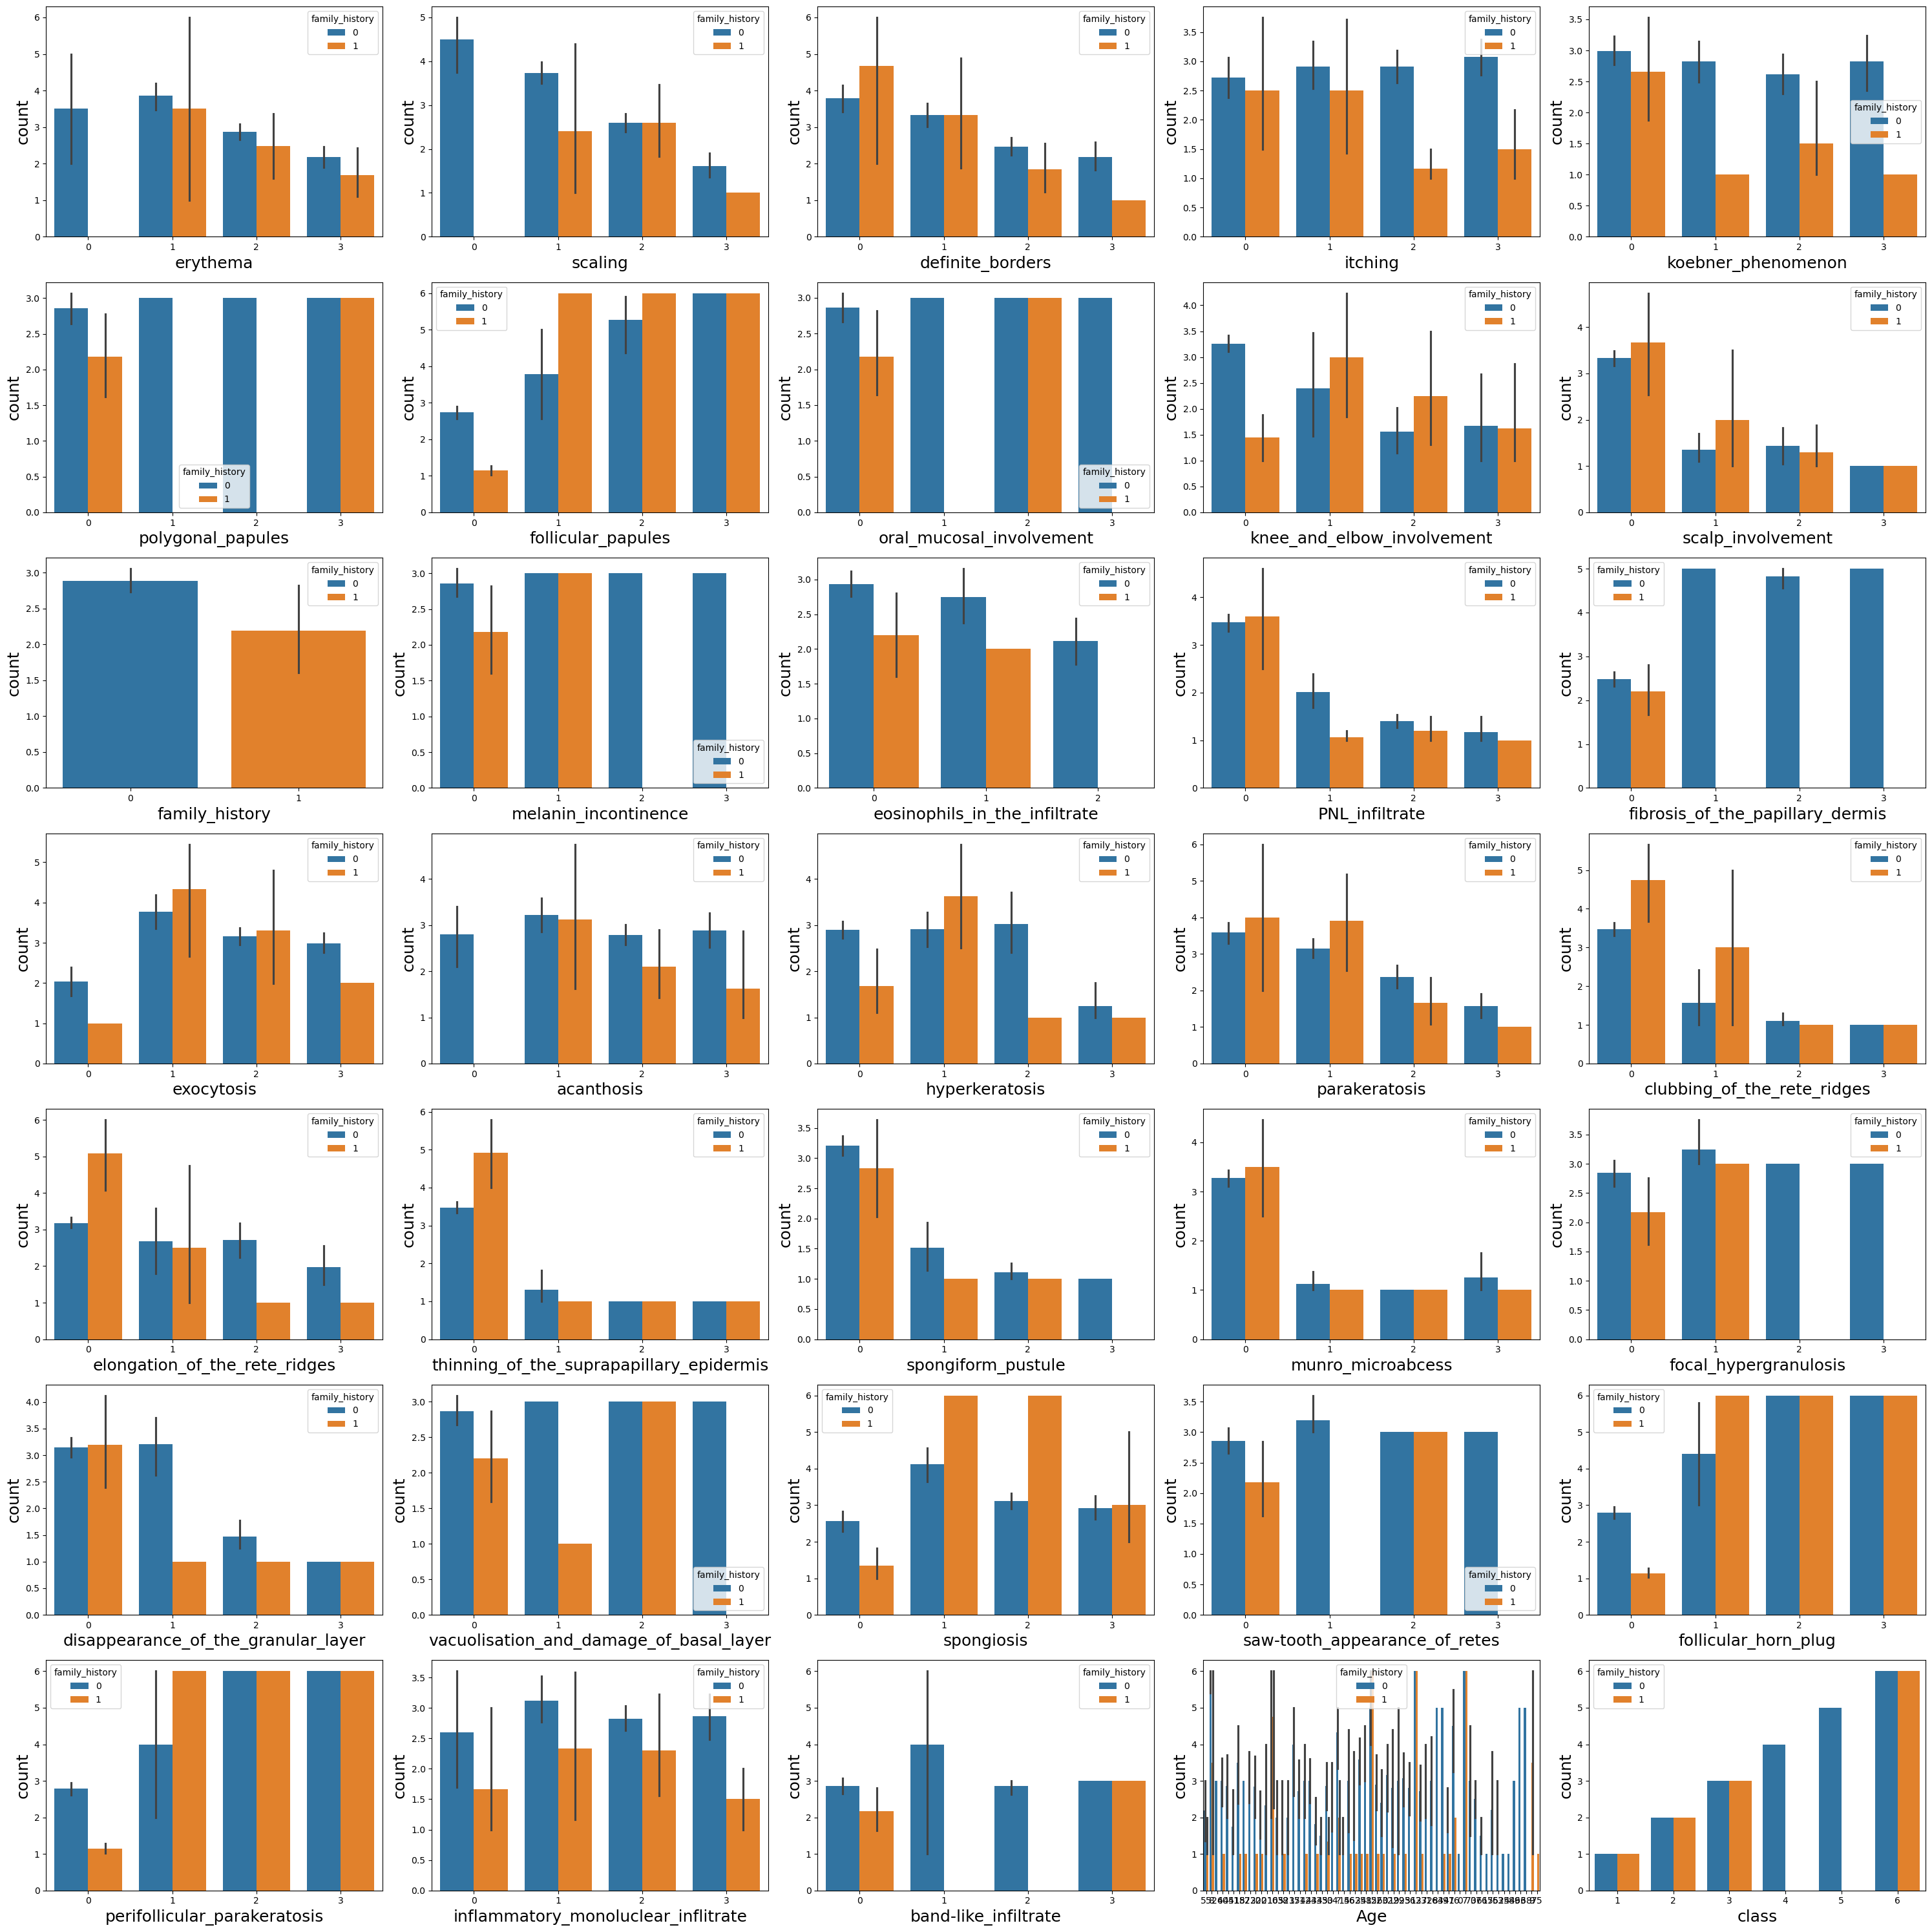

In [12]:
## Ploting the each column 
plt.figure(figsize=(30,30))              ## To fixed the canvas size
plotnumber = 1                           ## Initialize the plotnumber
for i in data.columns:                   ## Using foor loop to visualize the each column
    plt.subplot(7,5,plotnumber)          ## assign a plotnumber for each columns
    sns.barplot(x=data[i],y='class',data=data,hue='family_history')     ## using barplot to visualize how it affects the skin diseases
    plt.xlabel(i,fontsize=18)            ## change the font size of x label
    plt.ylabel('count',fontsize=18)      ## change the font size of y label
    plotnumber += 1                      ## increament the plot number by one
plt.tight_layout()                       ## using the tight layout to adjust space and don't overlap the  figure
plt.show()                               ## to show the figure

#### Insights:- 

* Overall, patients without a **family history** show higher counts for most common features like redness(**erythema**), scaling, itching, and skin thickening(features like **acanthosis**, **hyperkeratosis**, and **parakeratosis**).
  
* Patients with a family history show stronger association with specific features such as **follicular changes**, **keratin plugs**, and **deeper skin structure involvement**.


* This indicates that family history influences which symptoms and skin patterns are more likely to appear, but it does not alone determine the disease.

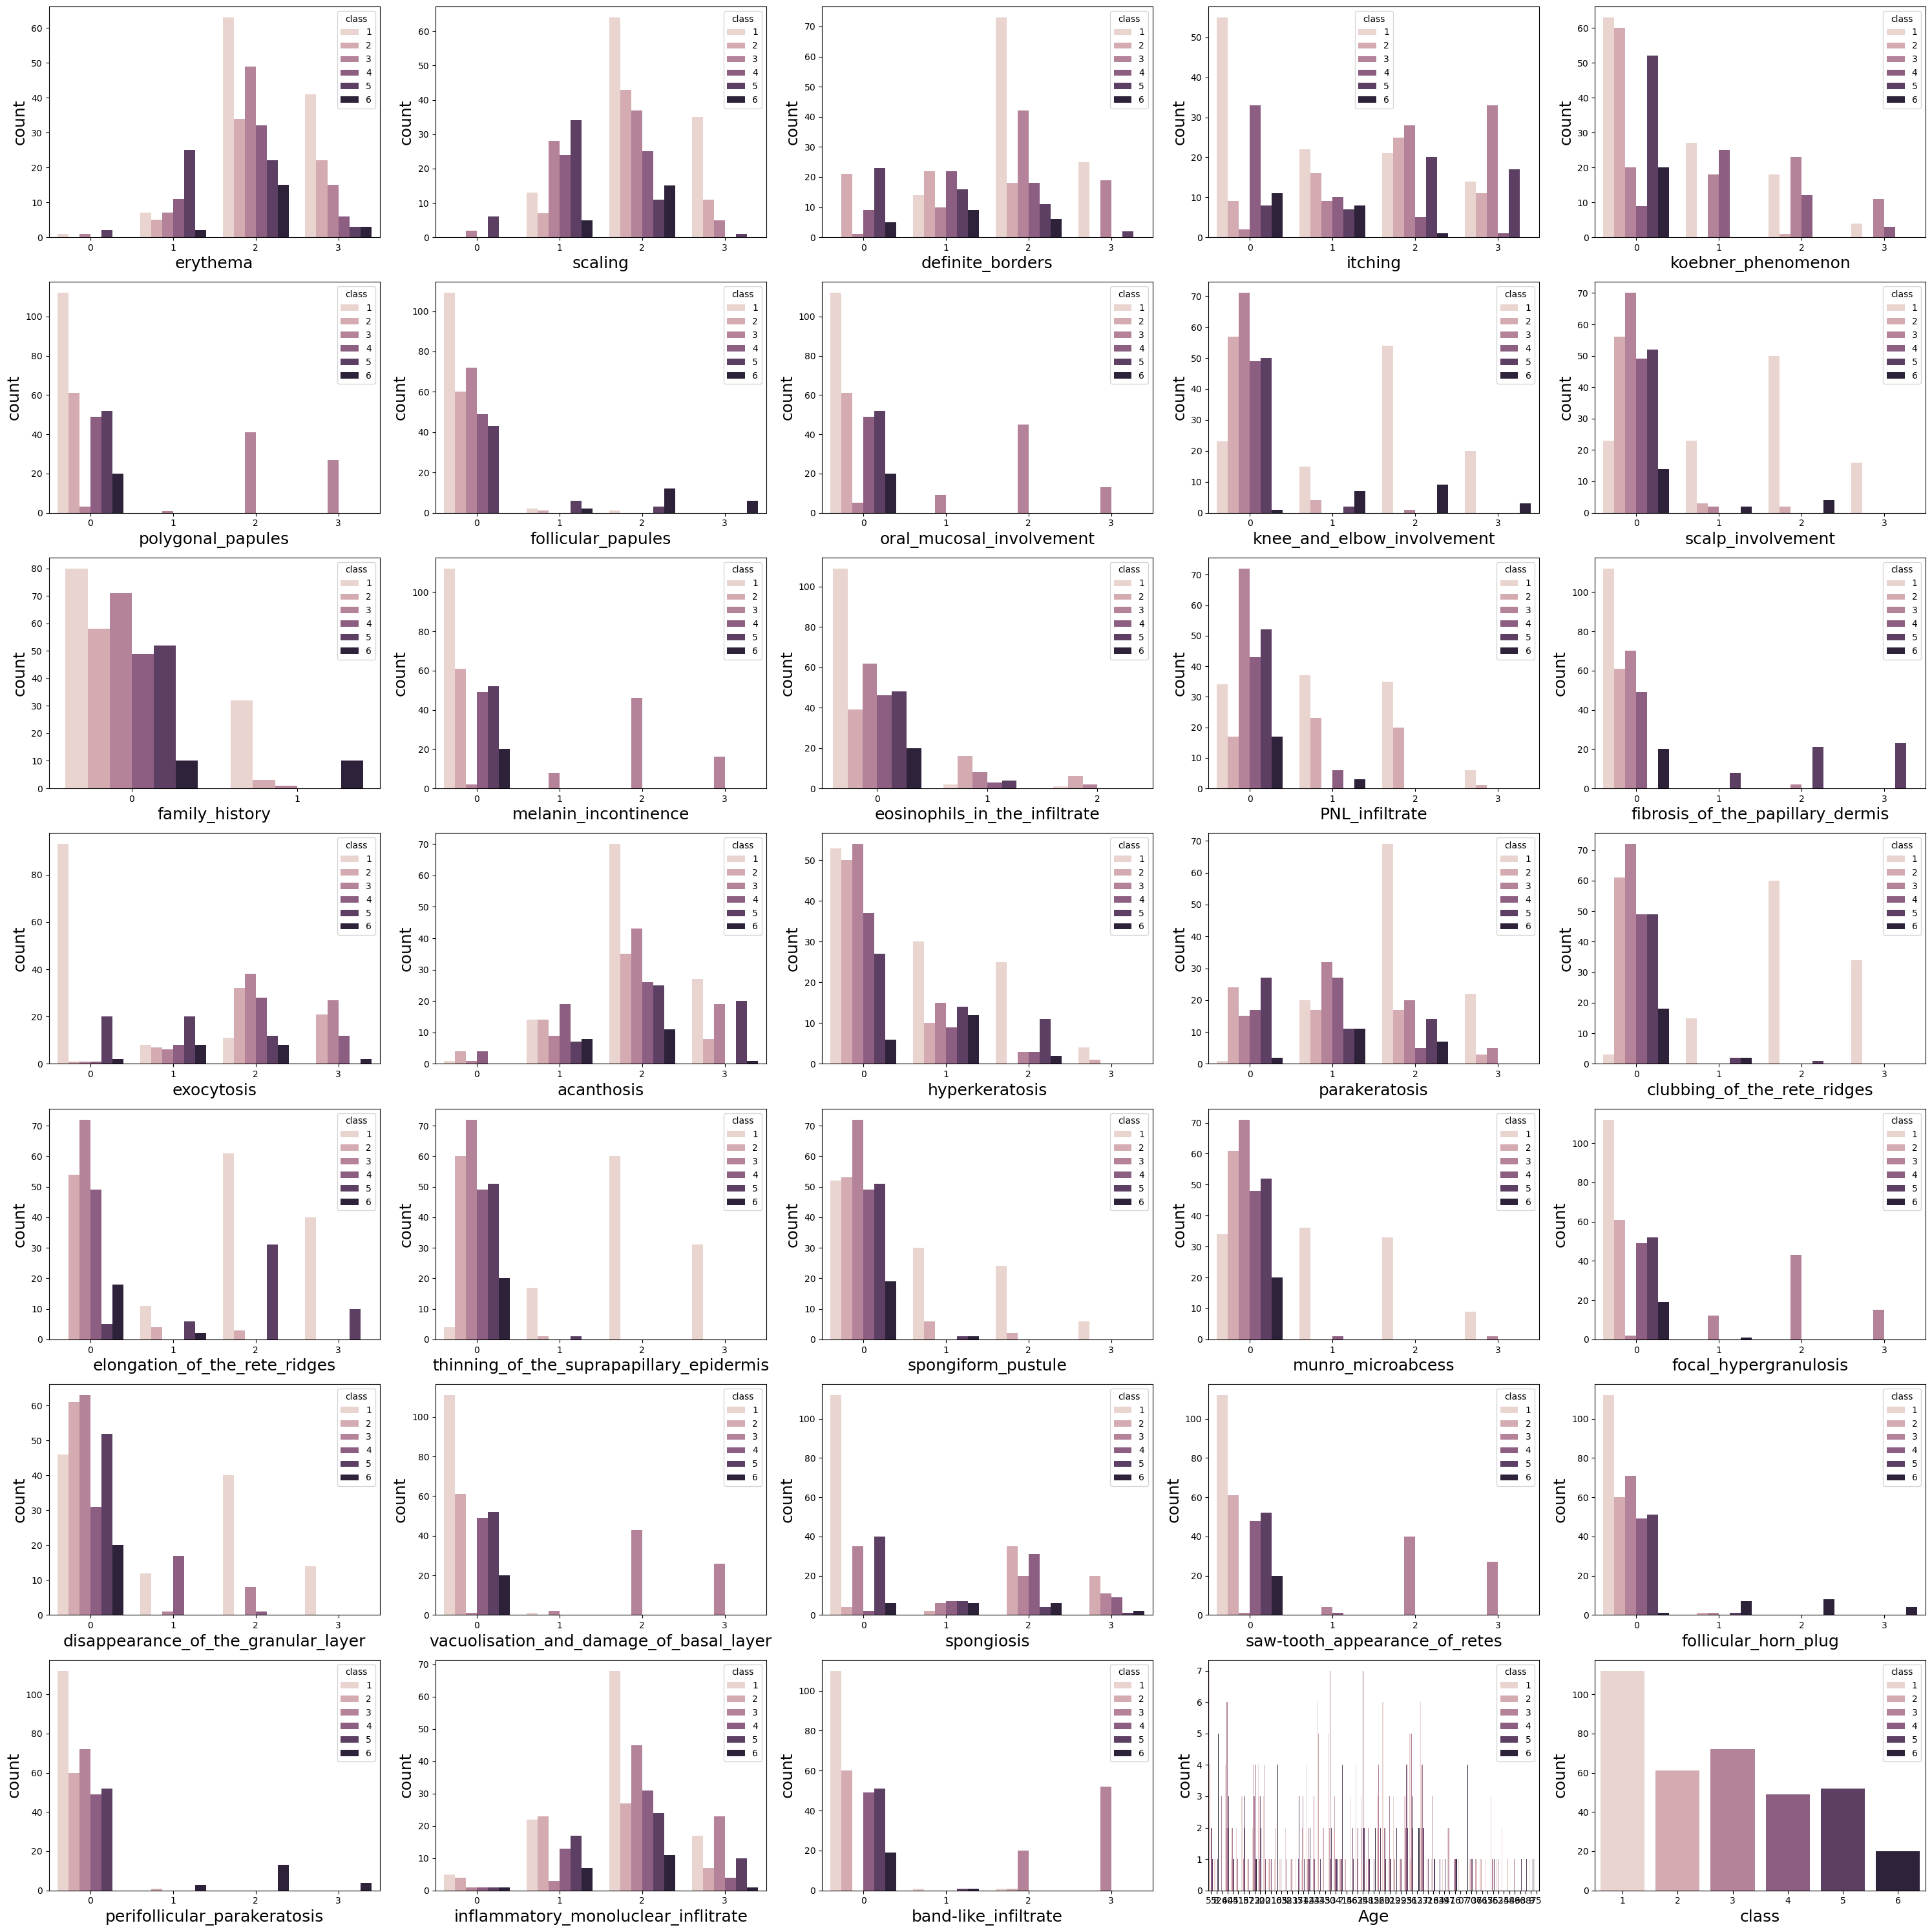

In [13]:
plt.figure(figsize=(30,30))              ## To fixed the canvas size
plotnumber = 1                           ## Initialize the plotnumber
for i in data:                   ## Using foor loop to visualize the each column
    plt.subplot(7,5,plotnumber)          ## assign a plotnumber for each columns
    sns.countplot(x=data[i],hue=data["class"])        ## using countplot to visualize how it affects the skin diseases
    plt.xlabel(i,fontsize=18)            ## change the font size of x label
    plt.ylabel('count',fontsize=18)      ## change the font size of y label
    plotnumber += 1                      ## increament the plot number by one
plt.tight_layout()                       ## using the tight layout to adjust space and don't overlap the  figure
plt.show()    

#### Insights:-

1. **When Most Features Are Absent**

    * Patients with absence of itching, Koebner phenomenon, papules, mucosal involvement, inflammatory infiltrates, and key histopathological features have the highest likelihood of Class 1 (Psoriasis).
    * Patients with absence of definite borders, involvement of knees/elbows/scalp, epidermal thickening, parakeratosis, and inflammatory infiltrates are most likely to have Class 2 (Seborrheic Dermatitis).
    * Patients lacking Koebner phenomenon, follicular papules, joint/scalp involvement, keratinization changes, and inflammatory infiltrates show the highest chance of Class 3 (Lichen Planus).
    * Patients with absence of most clinical and histological features, including itching, papules, hyperkeratosis, and immune infiltrates, are most likely associated with Class 4 (Pityriasis Rosea).
    * Patients showing minimal erythema, no scaling, no inflammatory or epidermal changes are most likely to have Class 5 (Chronic Dermatitis).
    * Patients without follicular involvement, keratin plugs, inflammatory infiltrates, and rete ridge changes show higher likelihood of Class 6 (Pityriasis Rubra Pilaris).

2. **Intermediate level of Features**

    * Patients with moderate erythema, scaling, well-defined borders, joint involvement, epidermal thickening, and inflammatory infiltrates most commonly correspond to Class 1 (Psoriasis).
    * Patients with moderate erythema, itching, polygonal papules, mucosal involvement, basal layer damage, and band-like infiltrate are most likely to have Class 3 (Lichen Planus).
    * Patients with moderate erythema, scaling, itching, exocytosis, spongiosis, and inflammatory infiltrates are most likely associated with Class 2 (Seborrheic Dermatitis).
    * Patients showing moderate erythema, Koebner phenomenon, parakeratosis, spongiosis, and inflammatory infiltrates are most consistent with Class 4 (Pityriasis Rosea).
    * Patients with moderate erythema, itching, fibrosis, epidermal thickening, and inflammatory infiltrates are more likely to have Class 5 (Chronic Dermatitis).
    * Patients with moderate scaling, follicular papules, scalp and joint involvement, follicular horn plugs, and perifollicular parakeratosis are most consistent with Class 6 (Pityriasis Rubra Pilaris).

3. **High level / Strong Feature Presence**
    
    * Patients showing severe erythema, scaling, sharply defined borders, joint and scalp involvement, marked epidermal hyperplasia, Munro microabscess, and inflammatory infiltrates have the highest probability of Class 1 (Psoriasis).
    * Patients with severe erythema, scaling, itching, eosinophils, spongiosis, and inflammatory infiltrates are most likely to have Class 2 (Seborrheic Dermatitis).
    * Patients with severe erythema, itching, Koebner phenomenon, polygonal papules, mucosal involvement, basal cell damage, and band-like infiltrates strongly indicate Class 3 (Lichen Planus).
    * Patients with marked erythema, Koebner phenomenon, exocytosis, spongiosis, and inflammatory infiltrates are most consistent with Class 4 (Pityriasis Rosea).
    * Patients with severe erythema, scaling, fibrosis, epidermal thickening, rete ridge elongation, and inflammation are most likely to have Class 5 (Chronic Dermatitis).
    * Patients with severe erythema, follicular papules, joint involvement, follicular plugs, perifollicular parakeratosis, and inflammation are most consistent with Class 6 (Pityriasis Rubra Pilaris).

4. **Family History Insight**

    * Patients without a family history of skin disease show higher likelihood of Class 1 (Psoriasis) and Class 3 (Lichen Planus), with moderate probability for Classes 2, 4, and 5.
    * Patients with a positive family history of skin disease show a higher likelihood of Class 1 (Psoriasis) and Class 6 (Pityriasis Rubra Pilaris).

## Data Preprocessing

* There is no null values present in dataset.
* There is no duplicate values.
* Only we need to change the type of age and replace the invalid values.


In [14]:
## checking for missing values in data
data.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [15]:
## checking for duplicates values
data.duplicated().sum()

np.int64(0)

In [16]:
data.loc[data['Age']=='?','Age']       ## checking for invalid values in Age Column

33     ?
34     ?
35     ?
36     ?
262    ?
263    ?
264    ?
265    ?
Name: Age, dtype: object

In [17]:
# Replace '?' with NaN
data['Age'] = data['Age'].replace('?', np.nan)

In [18]:
# Convert to numeric (It will turn NaN into actual NaN values)
data['Age'] = pd.to_numeric(data['Age'])

In [19]:
## Replacing NaN values by median
median_age = data['Age'].median()
data['Age'] = data['Age'].fillna(median_age)

In [20]:
## changing the data types of age to an integer 
data['Age'] = data['Age'].astype('int64')

In [21]:
data.Age.dtypes

dtype('int64')

#### Check For Outliers

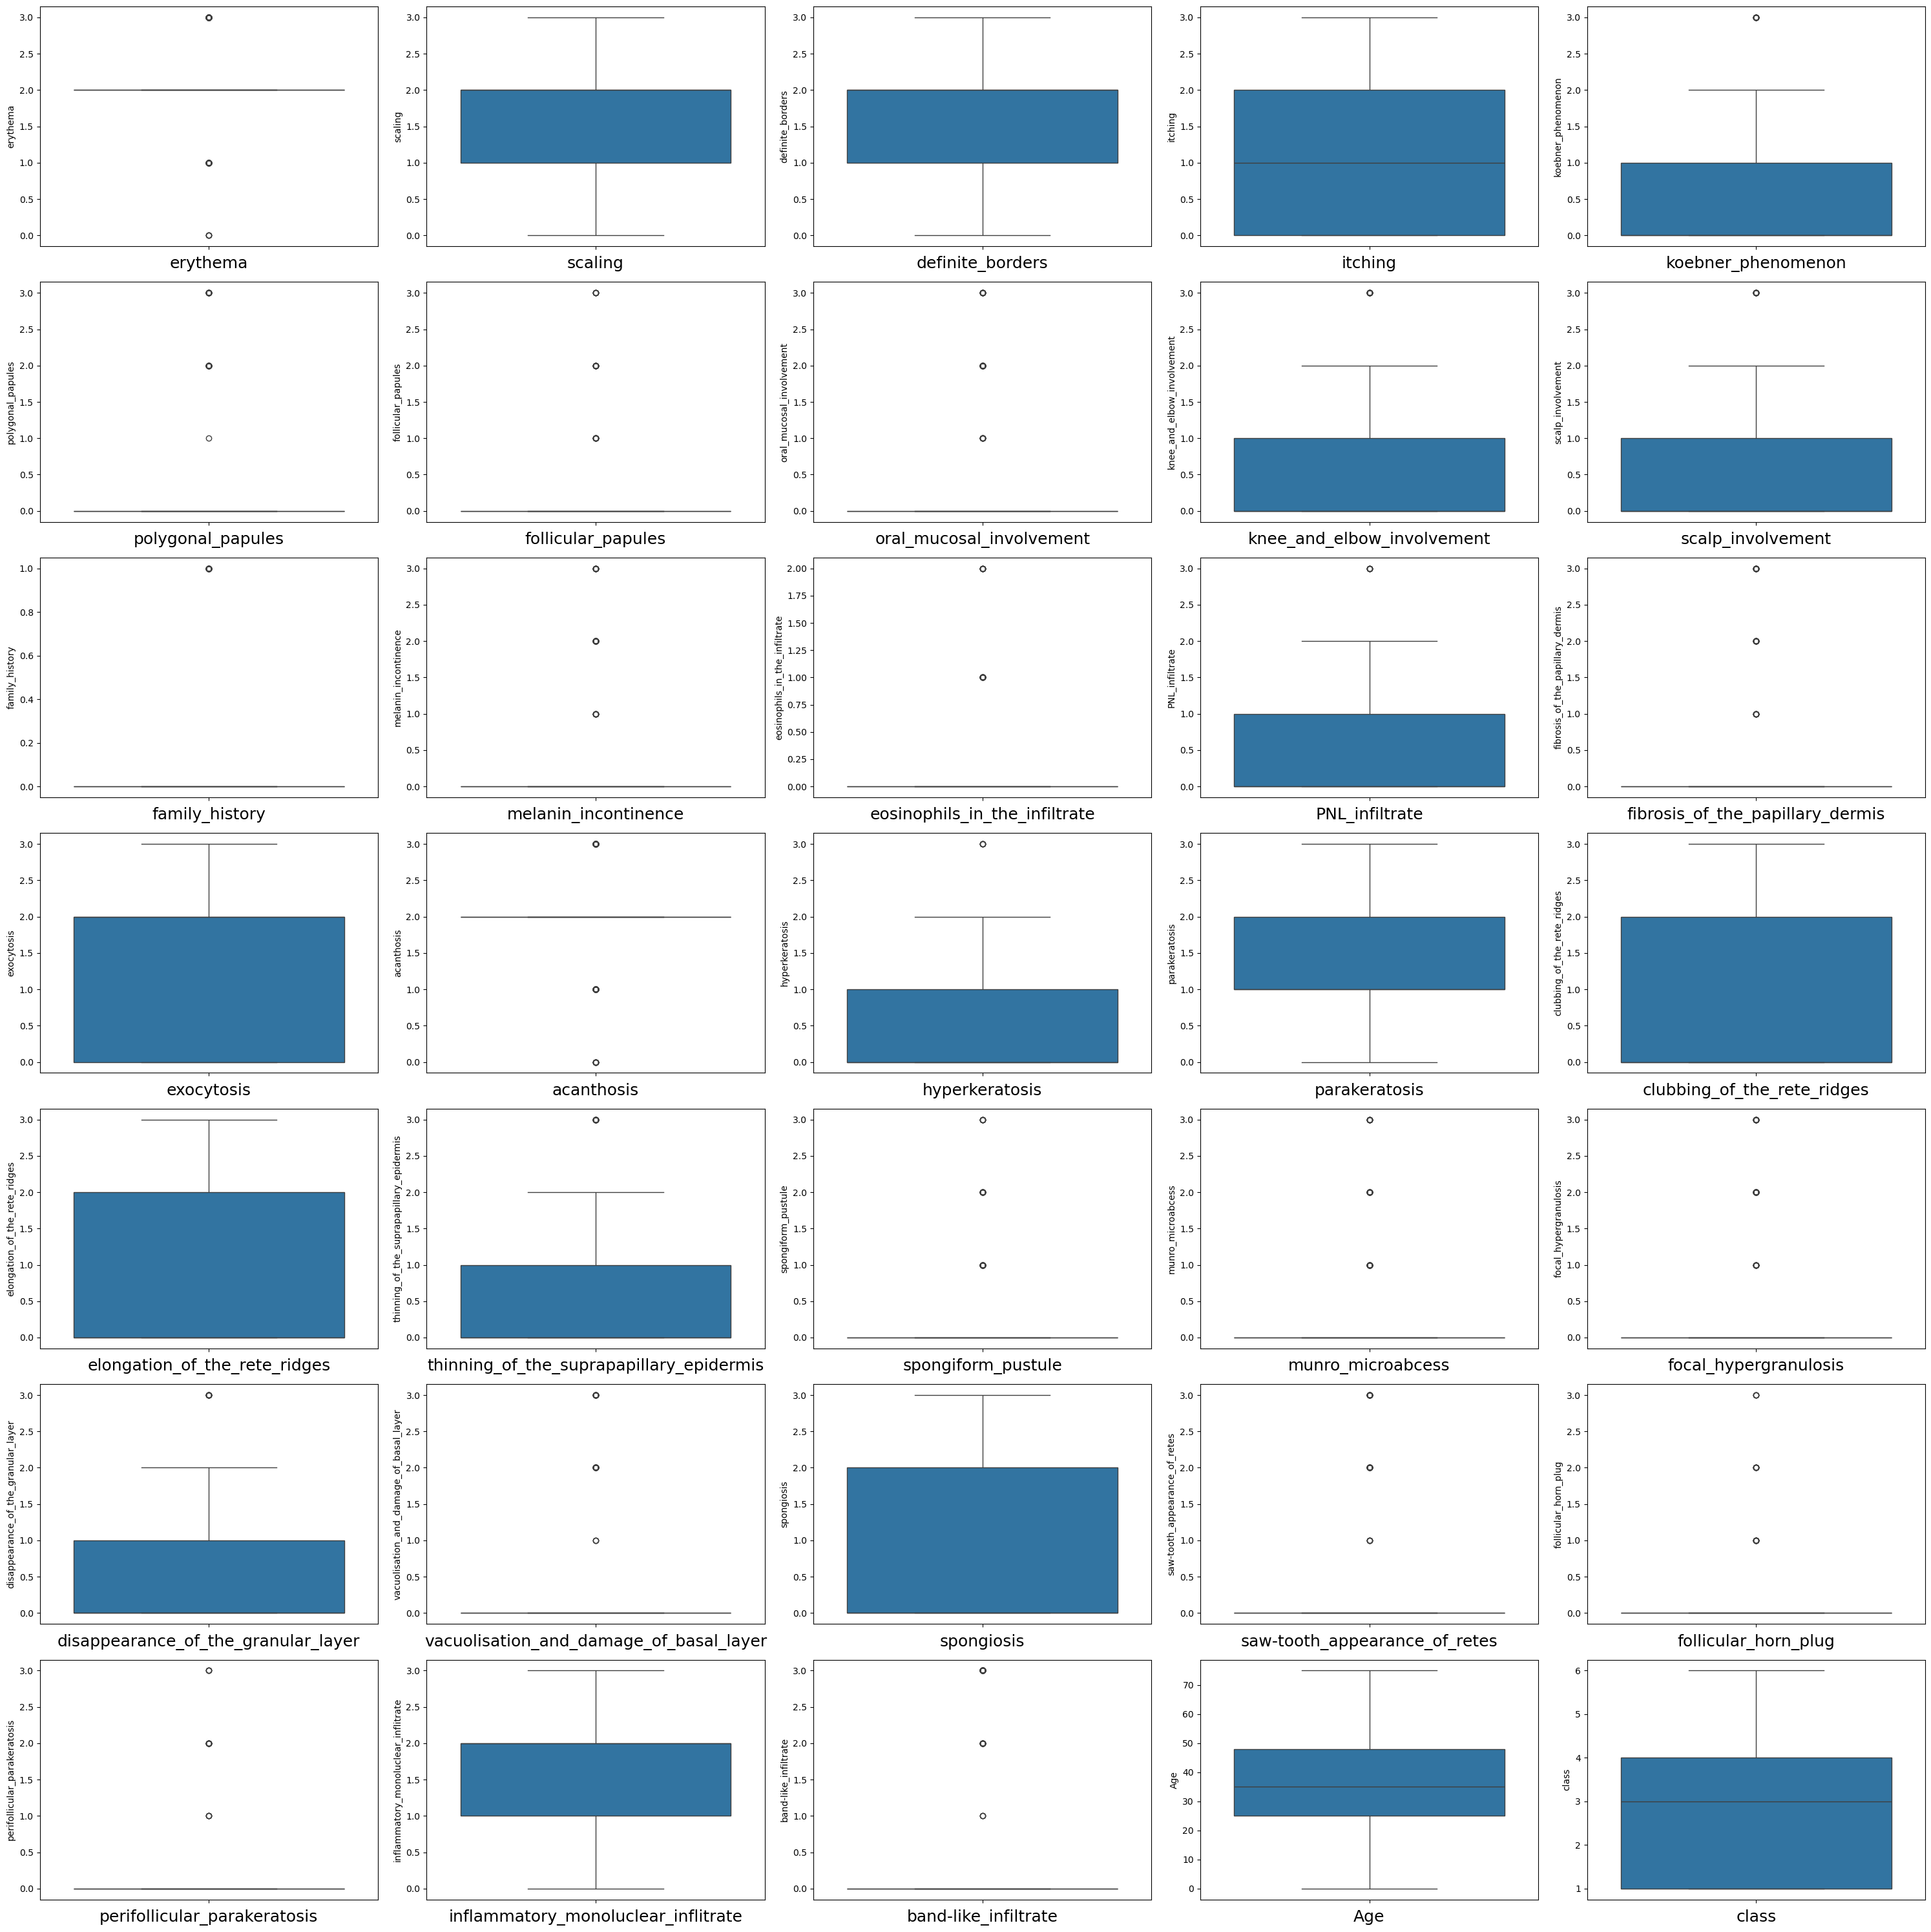

In [22]:
plt.figure(figsize=(30,30))              ## To fixed the canvas size
plotnumber = 1                           ## Initialize the plotnumber
for i in data.columns:                   ## Using foor loop to visualize the each column
    plt.subplot(7,5,plotnumber)          ## assign a plotnumber for each columns
    sns.boxplot(data[i])                ## using boxplot to know the outliers
    plt.xlabel(i,fontsize=18)            ## change the font size of x label
    plotnumber += 1                      ## increament the plot number by one
plt.tight_layout()                       ## using the tight layout to adjust space and don't overlap the  figure
plt.show()    

#### Insights:- 

* In the dataset, the family history feature has the value 1 if any of these diseases has been observed in the family, and 0 otherwise. The age feature simply represents the age of the patient.

* Every other feature clinical and histopathological was given a degree in the range of 0 to 3. Here, 0 indicates that the feature was not present, 3 indicates the largest amount possible, and 1, 2 indicate the relative intermediate values. So, for some feature the 1, 2 value considered as outlier but they are not.

* So, we keep them as it is.

## Feature Selection

<Axes: >

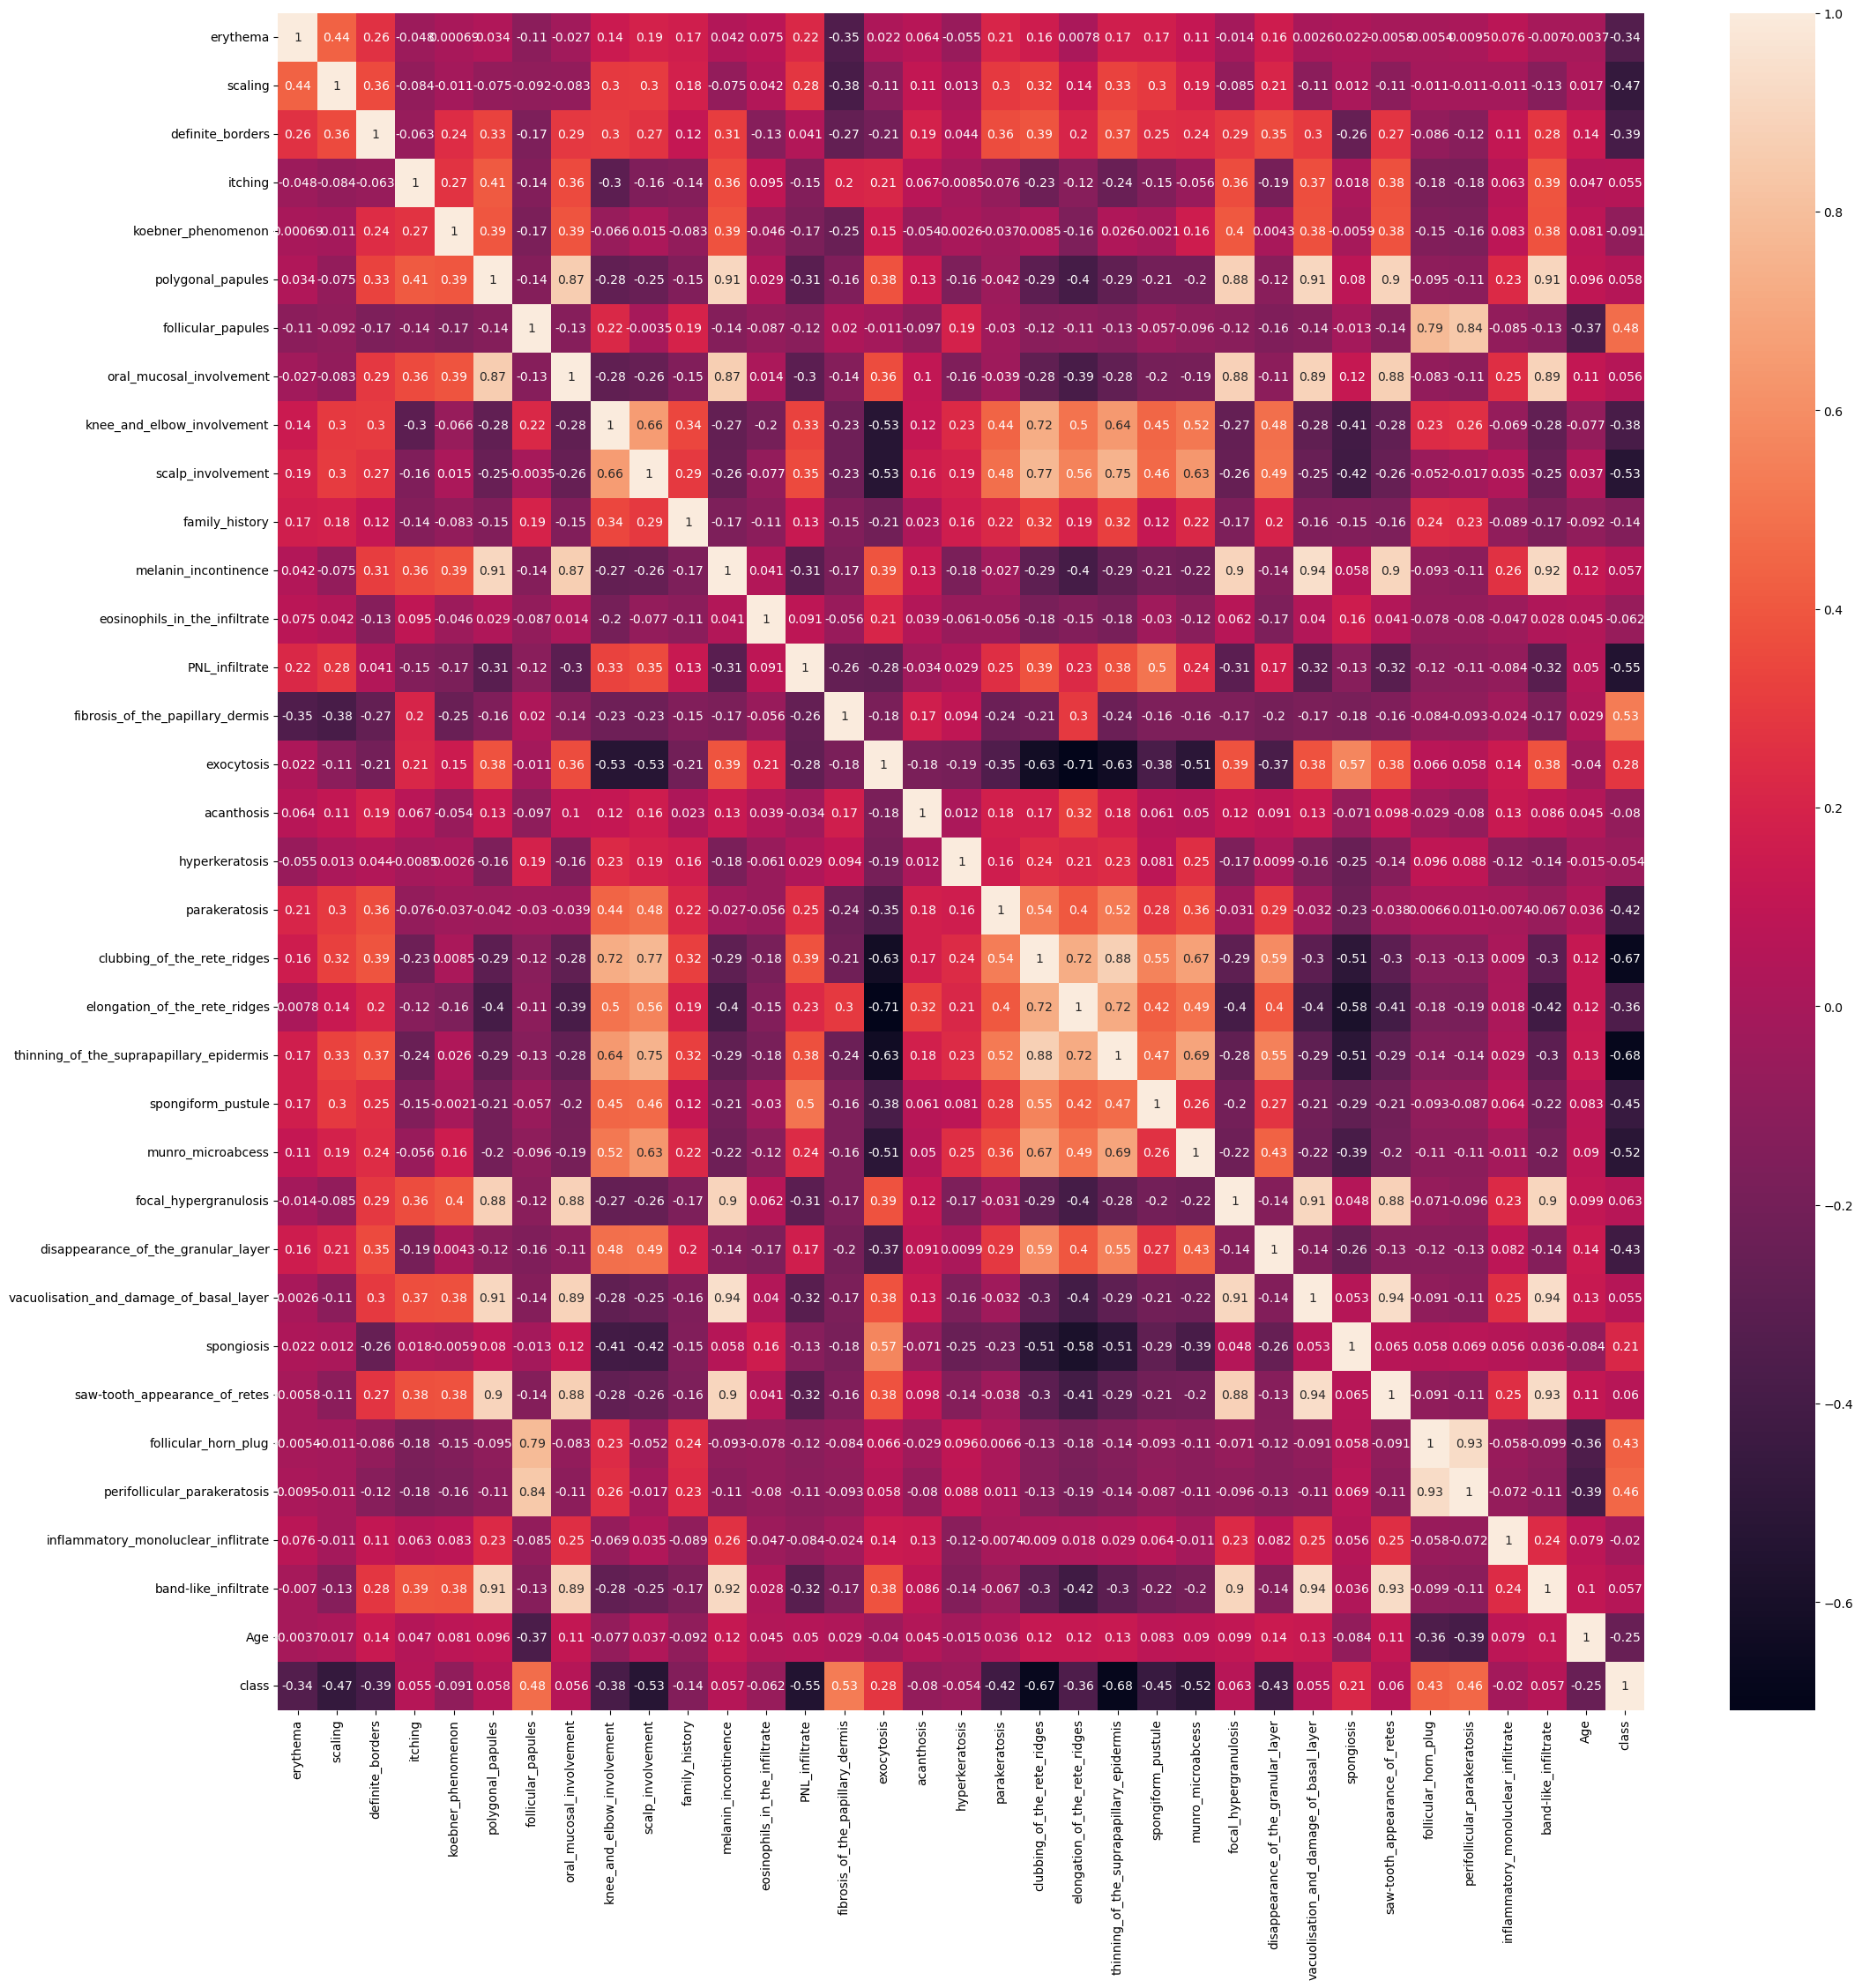

In [23]:
# Checking multicollinearity among input features and linearity between features and target.

plt.figure(figsize=(25,25))
sns.heatmap(data.corr(),annot=True)

## Insights:-
* As we can see,every feature is having good correlation with the target columns.
* The below input columns are highly correlated with other input columns:-
    * **polygonal_papules** and **melanin_incontinence**
    * **band-like_infiltrate** and **polygonal_papules**
    * **vacuolisation_and_damage_of_basal_layer** and **polygonal_papules**
    * **band-like_infiltrate** and **melanin_incontinence**
    * **vacuolisation_and_damage_of_basal_layer** and **melanin_incontinence**
    * **vacuolisation_and_damage_of_basal_layer** and **focal_hypergranulosis**
    * **saw-tooth_appearance_of_retes** and **vacuolisation_and_damage_of_basal_layer**
    * **vacuolisation_and_damage_of_basal_layer** and **band-like_infiltrate**
    * **saw-tooth_appearance_of_retes** and **band-like_infiltrate**
    * **follicular_horn_plug** and **perifollicular_parakeratosis**

* So, one of the columns will be delete 

In [24]:
## The below columns will be delete because it causes the high correaltion eith the input columns
cols = ['polygonal_papules','band-like_infiltrate','melanin_incontinence','focal_hypergranulosis','saw-tooth_appearance_of_retes','perifollicular_parakeratosis']
cols

['polygonal_papules',
 'band-like_infiltrate',
 'melanin_incontinence',
 'focal_hypergranulosis',
 'saw-tooth_appearance_of_retes',
 'perifollicular_parakeratosis']

In [25]:
data.drop(cols,axis=1,inplace=True)

In [26]:
data.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,follicular_horn_plug,inflammatory_monoluclear_inflitrate,Age,class
0,2,2,0,3,0,0,0,1,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,3,0,1,55,2
1,3,3,3,2,1,0,0,1,1,1,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,1,8,1
2,2,1,2,3,1,0,3,0,0,0,0,0,0,1,2,0,2,0,0,0,0,0,0,2,3,0,2,26,3
3,2,2,2,0,0,0,0,3,2,0,0,3,0,0,2,0,3,2,2,2,2,0,3,0,0,0,3,40,1
4,2,3,2,2,2,0,2,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,2,3,2,0,2,45,3


#### Split a data into X and Y


In [27]:
x= data.drop('class',axis=1)
y=data['class']

In [28]:
x

,erythema,scaling,definite_borders,itching,koebner_phenomenon,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,follicular_horn_plug,inflammatory_monoluclear_inflitrate,Age
0,2,2,0,3,0,0,0,1,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,3,0,1,55
1,3,3,3,2,1,0,0,1,1,1,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,1,8
2,2,1,2,3,1,0,3,0,0,0,0,0,0,1,2,0,2,0,0,0,0,0,0,2,3,0,2,26
3,2,2,2,0,0,0,0,3,2,0,0,3,0,0,2,0,3,2,2,2,2,0,3,0,0,0,3,40
4,2,3,2,2,2,0,2,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,2,3,2,0,2,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,2,25
362,3,2,1,0,1,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,1,0,1,0,2,36
363,3,2,2,2,3,0,2,0,0,0,2,0,0,3,3,0,0,0,0,0,0,0,0,3,0,0,2,28
364,2,1,3,1,2,0,2,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,2,0,0,2,50


In [29]:
y

0      2
1      1
2      3
3      1
4      3
      ..
361    4
362    4
363    3
364    3
365    1
Name: class, Length: 366, dtype: int64

#### Split a data for training and testing



In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)

In [31]:
## Since data is not balanced so we used SMOTE to balancing a data
from imblearn.over_sampling import SMOTE
sm=SMOTE()
x_smote,y_smote = sm.fit_resample(x_train,y_train)   # balancing training data

In [32]:
from collections import Counter
print('Actual Classes: ',Counter(y_train))
print('SMOTE Classes: ',Counter(y_smote))

Actual Classes:  Counter({1: 91, 3: 53, 2: 45, 5: 40, 4: 33, 6: 12})
SMOTE Classes:  Counter({1: 91, 2: 91, 5: 91, 4: 91, 3: 91, 6: 91})


In [33]:
x_smote

,erythema,scaling,definite_borders,itching,koebner_phenomenon,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,follicular_horn_plug,inflammatory_monoluclear_inflitrate,Age
0,2,3,2,0,0,0,0,2,3,0,0,2,0,0,2,2,2,2,2,3,2,1,0,0,0,0,2,33
1,2,2,0,2,0,0,0,0,0,0,1,1,0,2,2,0,2,0,0,0,0,0,0,0,3,0,2,47
2,1,1,0,2,0,1,0,0,0,0,0,0,2,1,2,1,0,0,1,0,0,0,0,0,0,0,2,18
3,2,2,0,2,1,0,0,0,0,0,0,0,0,2,0,0,2,0,0,0,0,0,0,0,3,0,3,70
4,2,2,1,2,0,0,0,0,0,0,0,1,0,2,2,0,2,0,0,0,0,0,0,0,2,0,2,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,2,2,1,0,0,2,0,2,0,0,0,0,0,2,2,0,1,0,0,0,0,0,0,0,2,2,2,7
542,2,2,0,1,0,2,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,2,1,2,8
543,2,1,1,0,0,2,0,2,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,2,0,13
544,2,2,1,0,0,2,0,1,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,2,2,2,7


In [34]:
y_smote

0      1
1      2
2      5
3      4
4      2
      ..
541    6
542    6
543    6
544    6
545    6
Name: class, Length: 546, dtype: int64

# Model Selection

### Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_smote,y_smote)

LogisticRegression()

In [36]:
lr_pred = lr.predict(x_test)
lr_pred

array([4, 4, 3, 6, 3, 6, 2, 1, 6, 5, 2, 1, 5, 2, 5, 1, 1, 5, 4, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 2, 5, 2, 6, 3, 5, 2, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 3, 1, 4, 1, 2, 5, 1, 1, 1, 4, 2, 3, 4, 3, 2, 3, 6,
       2, 6, 4, 2, 4, 3, 3, 5, 1, 1, 4, 1, 1, 1, 2, 3, 2, 3, 4, 5, 1, 5,
       4, 4, 3, 5])

In [37]:
## For Model Evaluation, we have to import confusion matrix,recall score,precision score,f1 score,accuracy score and classification report

from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report
acc= accuracy_score(y_test,lr_pred)
acc


0.9891304347826086

In [38]:
f1 = f1_score(y_test,lr_pred,average='weighted')
f1

0.9891198095966679

In [39]:
confusion_matrix(y_test,lr_pred)

array([[21,  0,  0,  0,  0,  0],
       [ 0, 15,  0,  1,  0,  0],
       [ 0,  0, 19,  0,  0,  0],
       [ 0,  0,  0, 16,  0,  0],
       [ 0,  0,  0,  0, 12,  0],
       [ 0,  0,  0,  0,  0,  8]])

In [40]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        21
           2       1.00      0.94      0.97        16
           3       1.00      1.00      1.00        19
           4       0.94      1.00      0.97        16
           5       1.00      1.00      1.00        12
           6       1.00      1.00      1.00         8

    accuracy                           0.99        92
   macro avg       0.99      0.99      0.99        92
weighted avg       0.99      0.99      0.99        92



### Support Vector Machine

In [41]:
from sklearn.svm import SVC
svc = SVC(random_state=10)
svc.fit(x_smote,y_smote)

SVC(random_state=10)

In [42]:
svc_pred = svc.predict(x_test)
svc_pred

array([4, 4, 3, 6, 3, 4, 2, 1, 6, 5, 2, 1, 5, 2, 5, 1, 1, 4, 2, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 6, 5, 2, 6, 3, 5, 2, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 2, 1, 4, 1, 4, 5, 1, 1, 1, 4, 2, 3, 4, 3, 4, 3, 6,
       4, 6, 4, 2, 4, 3, 3, 6, 1, 1, 4, 1, 1, 1, 2, 3, 2, 4, 4, 5, 1, 5,
       4, 4, 3, 5])

In [43]:
## Checking Accuracy
acc2= accuracy_score(y_test,svc_pred)
acc2

0.8804347826086957

In [44]:
## Checking F1 Score
f1_2 = f1_score(y_test,svc_pred,average='weighted')
f1_2

0.8827313111902629

In [45]:
confusion_matrix(y_test,svc_pred)

array([[21,  0,  0,  0,  0,  0],
       [ 0, 11,  0,  4,  0,  1],
       [ 0,  1, 17,  1,  0,  0],
       [ 0,  1,  0, 15,  0,  0],
       [ 0,  0,  0,  1, 10,  1],
       [ 0,  0,  0,  1,  0,  7]])

#### Hyperparameter Tuning

* **RandomizedSearchCV** is a method used to find the best hyperparameters for a machine-learning model.
* Instead of trying every possible combination (like GridSearchCV), it randomly picks some combinations and tests them.
* This makes it faster and still gives good results.

In [46]:
# Define hyperparameter grid for RandomizedSearchCV 
from sklearn.model_selection import RandomizedSearchCV
param_grid = {'C':[0.1,0.5,10,30,60,85,100],           # Regularization strength values to try
             'gamma':[0.1,0.001,0.0001,1],             # Kernel coefficient values for RBF/Sigmoid kernels
             'random_state': (list(range(1,20)))}      # Different random seeds to test model stability
model = SVC()
r_model = RandomizedSearchCV(model,param_distributions=param_grid,verbose=2,scoring='accuracy',cv=5,refit=True)       ## Initialize the RandomizedSearchCV
r_model.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END .....................C=0.1, gamma=1, random_state=6; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=6; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=6; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=6; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=6; total time=   0.0s
[CV] END .................C=0.1, gamma=0.001, random_state=8; total time=   0.0s
[CV] END .................C=0.1, gamma=0.001, random_state=8; total time=   0.0s
[CV] END .................C=0.1, gamma=0.001, random_state=8; total time=   0.0s
[CV] END .................C=0.1, gamma=0.001, random_state=8; total time=   0.0s
[CV] END .................C=0.1, gamma=0.001, random_state=8; total time=   0.0s
[CV] END ...............C=100, gamma=0.0001, random_state=17; total time=   0.0s
[CV] END ...............C=100, gamma=0.0001, ran

RandomizedSearchCV(cv=5, estimator=SVC(),
                   param_distributions={'C': [0.1, 0.5, 10, 30, 60, 85, 100],
                                        'gamma': [0.1, 0.001, 0.0001, 1],
                                        'random_state': [1, 2, 3, 4, 5, 6, 7, 8,
                                                         9, 10, 11, 12, 13, 14,
                                                         15, 16, 17, 18, 19]},
                   scoring='accuracy', verbose=2)

In [47]:
print(r_model.best_params_)        ## checking best parameters

{'random_state': 17, 'gamma': 0.0001, 'C': 100}


In [99]:
clf=SVC(C=100, gamma=0.0001,random_state=17) ## use best parameters for best score
clf.fit(x_smote,y_smote)

SVC(C=100, gamma=0.0001, random_state=17)

In [100]:
# Testing the model
y_clf = clf.predict(x_test)
y_clf

array([4, 4, 3, 6, 3, 2, 2, 1, 6, 5, 2, 1, 5, 2, 5, 1, 1, 5, 4, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 2, 5, 2, 6, 3, 5, 2, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 3, 1, 4, 1, 2, 5, 1, 1, 1, 4, 2, 3, 4, 3, 2, 3, 6,
       2, 6, 4, 2, 4, 3, 3, 6, 1, 1, 4, 1, 1, 1, 2, 3, 2, 3, 4, 5, 1, 5,
       4, 4, 3, 5])

In [101]:
## Accuracy Score
clf_acc = accuracy_score(y_test,y_clf)
clf_acc

0.967391304347826

In [102]:
## Checking F1 score
clf_f1 = f1_score(y_test,y_clf,average='weighted')
clf_f1

0.9673196998338776

### Random Forest

In [52]:
## Importing RandomForestClassifier and building a model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200)
rf.fit(x_smote,y_smote)

RandomForestClassifier(n_estimators=200)

In [53]:
rf_pred = rf.predict(x_test)
rf_pred

array([4, 4, 3, 6, 3, 6, 2, 1, 6, 5, 2, 1, 5, 2, 5, 1, 1, 5, 4, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 2, 5, 2, 1, 3, 5, 2, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 3, 1, 4, 1, 2, 5, 1, 1, 1, 4, 2, 3, 4, 3, 2, 3, 6,
       2, 6, 4, 2, 4, 3, 3, 5, 1, 1, 4, 1, 1, 1, 1, 3, 2, 3, 4, 5, 1, 5,
       4, 2, 3, 5])

In [54]:
## Accuracy Score
acc3 = accuracy_score(y_test,rf_pred)
acc3

0.9565217391304348

In [55]:
## F1 Score
f1_3 = f1_score(y_test,rf_pred,average='weighted')
f1_3

0.9561275447320329

#### HyperParameter Tuning 

In [56]:
# Define hyperparameter grid for RandomizedSearchCV 

from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(200,2000,10)]   ## list comprehension for total number of estimators
max_features = ['auto','sqrt']         ## maximum number of features allowed to try in individual tree 
max_depth = [int(x) for x in np.linspace(10,200,10)]     ## maximum number of height of tree
min_samples_split = [2,5,10,20]        ## minimum number of samples to be present in internal node
min_samples_leaf = [1,2,5,9]         ## minimum number of samples to be present in a leaf node
bootstrap = [True,False]   # Sampling with replacement or not

In [57]:
# dictionary for hyperparameters
random_grid = {'n_estimators':n_estimators,'max_features':max_features,'max_depth':max_depth,
              'min_samples_split':min_samples_split,'min_samples_leaf':min_samples_leaf,'bootstrap':bootstrap}

rf_clf1 = RandomForestClassifier(random_state=39)
rf_hy = RandomizedSearchCV(estimator=rf_clf1,scoring='accuracy',param_distributions=random_grid,n_iter=100,
                           cv=5,verbose=2,random_state=49,n_jobs=-1)

# estimators ---> numberr of decision tree
# scoring -----> to measure the performance
# param_distribution -----> hyperparameters values 
# n_iter ------> no.of iteration
# cv ----> totla numberr of folds
# verbose --------> it will prints messages
# n_jobs -----> number of jobs means processor and -1 indicates all processor run in parallel


rf_hy.fit(x_train,y_train)                      ## it is used to fit training data on randomsearch cv
rf_best_params = rf_hy.best_params_                ## it is used to give best parameters
print(f"Best Parameters: {rf_best_params}")        ## printing best parameters


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'n_estimators': 1800, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 73, 'bootstrap': False}


In [58]:
rf_clf2 = RandomForestClassifier(n_estimators= 1800, min_samples_split=5, min_samples_leaf=1, max_features= 'sqrt', max_depth= 73, bootstrap= False)
rf_clf2.fit(x_smote,y_smote)

RandomForestClassifier(bootstrap=False, max_depth=73, min_samples_split=5,
                       n_estimators=1800)

In [59]:
## Predicting
y_clf2 = rf_clf2.predict(x_test) 
y_clf2

array([4, 4, 3, 6, 3, 6, 2, 1, 6, 5, 2, 1, 5, 2, 5, 1, 1, 5, 4, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 2, 5, 2, 1, 3, 5, 2, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 3, 1, 4, 1, 2, 5, 1, 1, 1, 4, 2, 3, 4, 3, 2, 3, 6,
       2, 6, 4, 2, 4, 3, 3, 5, 1, 1, 4, 1, 1, 1, 1, 3, 2, 3, 4, 5, 1, 5,
       4, 2, 3, 5])

In [60]:
## Accuracy Score
clf_acc2 = accuracy_score(y_test,y_clf2)
clf_acc2

0.9565217391304348

In [61]:
## F1 Score
clf_f1_2 = f1_score(y_test,y_clf2,average='weighted')
clf_f1_2

0.9561275447320329

### KNN

In [62]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_smote,y_smote)

KNeighborsClassifier()

In [63]:
knn_pred = knn.predict(x_test)
knn_pred

array([4, 2, 3, 6, 3, 2, 2, 1, 6, 5, 3, 2, 5, 4, 5, 1, 1, 5, 2, 4, 1, 2,
       2, 1, 3, 3, 3, 4, 3, 3, 1, 1, 4, 2, 5, 2, 6, 3, 5, 4, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 2, 1, 4, 5, 2, 5, 1, 1, 1, 4, 2, 3, 4, 4, 2, 3, 6,
       2, 6, 4, 4, 4, 3, 3, 6, 1, 1, 4, 1, 1, 1, 2, 3, 2, 4, 4, 4, 1, 2,
       4, 4, 3, 5])

In [64]:
acc4 = accuracy_score(y_test,knn_pred)
acc4

0.8152173913043478

In [65]:
f1_4 = f1_score(y_test,knn_pred,average='weighted')
f1_4

0.8184789603267864

In [66]:
error_rate = []

for i in range(1,10):
    KNN = KNeighborsClassifier(n_neighbors=i)
    KNN.fit(x_smote,y_smote)
    KNN_pred = KNN.predict(x_test)
    error_rate.append(np.mean(KNN_pred != y_test))

In [67]:
error_rate

[np.float64(0.09782608695652174),
 np.float64(0.08695652173913043),
 np.float64(0.15217391304347827),
 np.float64(0.15217391304347827),
 np.float64(0.18478260869565216),
 np.float64(0.16304347826086957),
 np.float64(0.14130434782608695),
 np.float64(0.13043478260869565),
 np.float64(0.13043478260869565)]

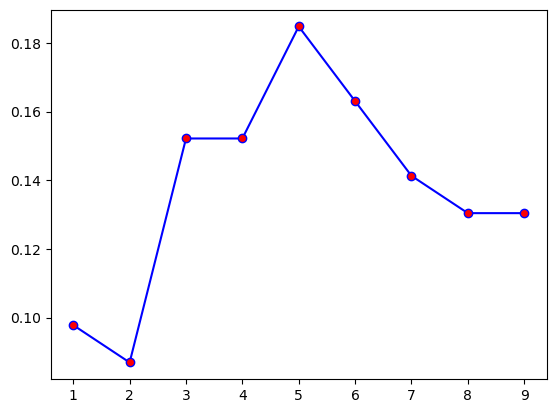

In [68]:
plt.plot(range(1,10),error_rate,color='blue',marker='o',markerfacecolor='red')

### Decision Tree

In [69]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_smote,y_smote)

DecisionTreeClassifier()

In [70]:
dt_pred = dt.predict(x_test)
dt_pred

array([4, 4, 3, 6, 3, 6, 2, 1, 6, 5, 4, 1, 5, 2, 5, 1, 1, 5, 4, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 2, 5, 2, 4, 3, 5, 2, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 3, 1, 4, 1, 2, 5, 1, 1, 1, 4, 2, 3, 4, 3, 2, 3, 4,
       2, 6, 4, 4, 4, 3, 3, 5, 1, 1, 4, 1, 1, 1, 1, 3, 2, 3, 4, 5, 1, 5,
       4, 2, 3, 5])

In [71]:
acc5 = accuracy_score(y_test,dt_pred)
acc5

0.9239130434782609

In [72]:
f1_5 = f1_score(y_test,dt_pred,average='weighted')
f1_5

0.9232987326934539

In [73]:
print(classification_report(y_test,dt_pred))# it will give precision,recall,f1 scores and accuracy  

              precision    recall  f1-score   support

           1       0.95      1.00      0.98        21
           2       0.92      0.75      0.83        16
           3       1.00      1.00      1.00        19
           4       0.75      0.94      0.83        16
           5       1.00      1.00      1.00        12
           6       1.00      0.75      0.86         8

    accuracy                           0.92        92
   macro avg       0.94      0.91      0.92        92
weighted avg       0.93      0.92      0.92        92



#### Hyperparameter Tuning

* **GridSearchCV** is a method used to find the best hyperparameters for a machine-learning model.
* It works by trying every possible combination of the hyperparameters you give it.
* This makes it very thorough, but sometimes slow if you have many values.

In [74]:
## crearing dictionary for hyperparameters
from sklearn.model_selection import GridSearchCV
params = {'criterion':('gini','entropy'),          # Methods to measure quality of a split
         'splitter':('random','best'),             # To choose split at each node
         'max_depth':(list(range(1,30))),          # Maximum height of the tree
         'min_samples_split':[2,5,7,10],           # Minimum samples required to split an internal node
         'min_samples_leaf':list(range(1,20))}     # Minimum samples required in a leaf node

tree_clf = DecisionTreeClassifier(random_state=9)
tree_hy = GridSearchCV(tree_clf,params,scoring='accuracy',n_jobs=-1,verbose=2,cv=3)       ## Initialize the GridSearchCV


# verbose=2 = show training progress in a clean, readable way.
#n_jobs = -1 =  use all CPU cores to make training faster.

tree_hy.fit(x_train,y_train)                    ## fit a data for hyperparameter tuning
best_params = tree_hy.best_params_             ## Best Parameters given by using hyperparameter tuning
print(f"Best Parameters: {best_params}")       ## Printing the best parameters  

Fitting 3 folds for each of 8816 candidates, totalling 26448 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}


In [75]:
dt1 = DecisionTreeClassifier(criterion='gini',max_depth=7,min_samples_split=2,min_samples_leaf=1,splitter='best')
dt1.fit(x_smote,y_smote)

DecisionTreeClassifier(max_depth=7)

In [76]:
## Prediction
dt_pred1 = dt1.predict(x_test)
dt_pred1

array([4, 4, 3, 1, 3, 6, 2, 1, 6, 5, 4, 1, 5, 2, 5, 1, 1, 5, 4, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 2, 5, 2, 4, 3, 5, 2, 1, 4, 3, 4,
       1, 1, 3, 3, 6, 3, 1, 4, 1, 2, 5, 1, 1, 1, 4, 4, 3, 4, 3, 2, 3, 2,
       2, 6, 4, 4, 4, 3, 3, 5, 1, 1, 4, 1, 1, 1, 1, 3, 2, 3, 4, 5, 1, 5,
       4, 2, 3, 5])

In [77]:
## checking accuracy by using hyperparameter tuning
acc_hy_dt = accuracy_score(y_test,dt_pred1)
acc_hy_dt

0.8913043478260869

In [78]:
## checking F1 score 
f1_hy_dt = f1_score(y_test,dt_pred1,average='weighted')
f1_hy_dt

0.8848325837081458

### Bagging

In [79]:
from sklearn.ensemble import BaggingClassifier
bagg = BaggingClassifier(estimator=lr,n_estimators=100,n_jobs=-1)
bagg.fit(x_smote,y_smote)

BaggingClassifier(estimator=LogisticRegression(), n_estimators=100, n_jobs=-1)

In [80]:
#prediction
bagg_pred_test =bagg.predict(x_test)
bagg_pred_train = bagg.predict(x_smote)

In [81]:
# accuracy
train_acc = accuracy_score(y_smote, bagg_pred_train)
test_acc  = accuracy_score(y_test, bagg_pred_test)

In [82]:
f1_bag = f1_score(y_test, bagg_pred_test, average='weighted')

In [83]:
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)
print("F1 Score:", f1_bag)

Training Accuracy: 0.9963369963369964
Testing Accuracy: 0.9891304347826086
F1 Score: 0.9891198095966679


In [84]:
confusion_matrix(y_test, bagg_pred_test)

array([[21,  0,  0,  0,  0,  0],
       [ 0, 15,  0,  1,  0,  0],
       [ 0,  0, 19,  0,  0,  0],
       [ 0,  0,  0, 16,  0,  0],
       [ 0,  0,  0,  0, 12,  0],
       [ 0,  0,  0,  0,  0,  8]])

### ANN

In [85]:
## importing libraries of neural network
from sklearn.neural_network import MLPClassifier
ann = MLPClassifier(hidden_layer_sizes=(250,6),
                   learning_rate_init=0.001,
                   max_iter=300,random_state=69)

ann.fit(x_smote,y_smote)

MLPClassifier(hidden_layer_sizes=(250, 6), max_iter=300, random_state=69)

In [86]:
ann_test_pred = ann.predict(x_test)
ann_train_pred = ann.predict(x_train)
ann_test_pred

array([4, 4, 3, 6, 3, 6, 2, 1, 6, 5, 2, 1, 5, 2, 5, 1, 1, 5, 4, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 2, 5, 2, 1, 3, 5, 2, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 3, 1, 4, 1, 2, 5, 1, 1, 1, 4, 2, 3, 4, 3, 2, 3, 6,
       2, 6, 4, 2, 4, 3, 3, 5, 1, 1, 4, 1, 1, 1, 1, 3, 2, 3, 4, 5, 1, 5,
       4, 2, 3, 5])

In [87]:
## evaluating the model 
acc6 = accuracy_score(y_test,ann_test_pred)
acc6

0.9565217391304348

In [88]:
f1_6 = f1_score(y_test,ann_test_pred,average='weighted')
f1_6

0.9561275447320329

### Gradient Boosting

In [89]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(x_smote,y_smote)

GradientBoostingClassifier()

In [90]:
gb_pred = gb.predict(x_test)
gb_pred

array([4, 4, 3, 6, 3, 6, 2, 1, 6, 5, 4, 1, 5, 2, 5, 1, 1, 5, 4, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 2, 5, 2, 4, 3, 5, 2, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 3, 1, 4, 1, 2, 5, 1, 1, 1, 4, 2, 3, 4, 3, 2, 3, 2,
       2, 6, 4, 2, 4, 3, 3, 5, 1, 1, 4, 1, 1, 1, 1, 3, 2, 3, 4, 5, 1, 5,
       4, 2, 3, 5])

In [91]:
acc7 = accuracy_score(y_test,gb_pred)
acc7

0.9347826086956522

In [92]:
f1_7 = f1_score(y_test,gb_pred,average='weighted')
f1_7

0.9337583984962261

#### Hyperparameter Tuning

In [93]:
gb_grid = {'learning_rate':[0.01,0.03,0.06,0.1],
          'max_depth':[5,6,7,8,9,10],
          'n_estimators':[50,65,80,100]}

gb1 = GradientBoostingClassifier(random_state=82)
gb_hy = RandomizedSearchCV(estimator=gb1,scoring='f1',param_distributions=gb_grid,n_iter=100,cv=5,verbose=2,random_state=42,n_jobs=-1)

gb_hy.fit(x_smote,y_smote)
gb_best_params = gb_hy.best_params_
print('Best Parameters: ',gb_best_params)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Parameters:  {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.01}


In [94]:
gb3 = GradientBoostingClassifier(n_estimators=50,max_depth=5,learning_rate=0.01)
gb3.fit(x_smote,y_smote)
gb3_pred = gb3.predict(x_test)
gb3_pred

array([4, 4, 3, 6, 3, 6, 4, 1, 6, 5, 4, 1, 5, 2, 5, 1, 1, 5, 4, 4, 1, 2,
       2, 1, 3, 3, 5, 4, 3, 3, 1, 1, 4, 2, 5, 2, 4, 3, 5, 2, 1, 4, 3, 4,
       6, 1, 3, 3, 6, 3, 1, 4, 1, 2, 5, 1, 1, 1, 4, 2, 3, 4, 3, 4, 3, 4,
       2, 6, 4, 2, 4, 3, 3, 5, 1, 1, 4, 1, 1, 1, 1, 3, 2, 3, 4, 5, 1, 5,
       4, 2, 3, 5])

In [95]:
acc_gb_hy = accuracy_score(y_test,gb3_pred)
acc_gb_hy

0.9130434782608695

In [96]:
f1_gb_hy = f1_score(y_test,gb3_pred,average='weighted')
f1_gb_hy

0.9120996990056646

## Model Comparison Report

In [103]:
# creating model comparison report using DataFrame
score = pd.DataFrame({"Models":["LogisticRegression","SupportVectorClassifier","RandomForestClassifier","KNeighborsClassifier","DecisionTreeClassifier",'BaggingClassifier',"ANN",'GradientBoosting'],
                     "Accuracy":[acc*100,acc2*100,acc3*100,acc4*100,acc5*100,test_acc*100,acc6*100,acc7*100],
                      "f1_score":[f1*100,f1_2*100,f1_3*100,f1_4*100,f1_5*100,f1_bag,f1_6*100,f1_7*100],
                     "With Hyperparameter Tunning":["-",clf_acc*100,clf_acc2*100,"-",acc_hy_dt*100,'-',"-",acc_gb_hy*100],
                     })

In [104]:
score

,Models,Accuracy,f1_score,With Hyperparameter Tunning
0,LogisticRegression,98.913043,98.911981,-
1,SupportVectorClassifier,88.043478,88.273131,96.73913
2,RandomForestClassifier,95.652174,95.612754,95.652174
3,KNeighborsClassifier,81.521739,81.847896,-
4,DecisionTreeClassifier,92.391304,92.329873,89.130435
5,BaggingClassifier,98.913043,0.989120,-
6,ANN,95.652174,95.612754,-
7,GradientBoosting,93.478261,93.375840,91.304348


## Conclusion of Model Comparison Report

I have evaluated eight algorithms for training the model: **Logistic Regression, K-Nearest Neighbors, Support Vector Classifier, Decision Tree, Random Forest,GradientBoosting,BaggingClassifier and ANN (MLP Classifier)**. Among these, Logistic Regression achieved the highest accuracy of **98.91%**, surpassing all other algorithms. The corresponding error rate indicating that the model makes very few misclassifications. The predictions are consistent, reliable, and suitable for real-world application. Given its high performance, **Logistic Regression** is recommended for the early detection of skin diseases in patients, enabling timely intervention and improved healthcare outcomes. Additionally, the simplicity and interpretability of Logistic Regression make it a practical choice for deployment in clinical settings.

## Suggestion to the Doctor:-

* **Redness (erythema) and scaling** appear in almost all skin diseases, so they are very common symptoms. This means that seeing redness or scaling alone is not enough to identify the exact disease, but they help us know that the disease is inflammatory in nature.

* Diseases with clearly **defined borders** are easier to recognize, because some skin conditions form sharp, well-outlined patches. When borders are not clear, the disease is usually more spread out and inflammatory.

* **Itching** is very helpful in differentiating diseases. Some skin diseases cause severe itching, while others cause little or no itching. So, asking the patient about itching is very important during diagnosis.

* **Koebner phenomenon** is seen only in certain diseases. If new skin lesions appear after scratching or injury, it gives a strong hint toward specific skin conditions and should not be ignored.

* **Polygonal papules** and **follicular papules** appear in very few diseases. When these types of lesions are seen, they strongly point toward particular diagnoses and help reduce confusion.

* **Oral mucosal involvement** is rare but important. If the mouth is affected along with skin lesions, doctors should consider specific diseases that commonly involve mucosal areas.

* Some diseases mostly affect the knees, elbows, and scalp. When **lesions** are found in these areas, it helps doctors quickly think of common chronic plaque-type skin diseases.

* **Family history** plays a role in some skin diseases. If close relatives have similar skin problems, it increases the chance that the disease may be inherited.

* **Skin biopsy** features like thickened skin, scaling layers, and abnormal cells vary across diseases. This shows why laboratory and microscopic examination is important when visual symptoms overlap.

* Certain microscopic findings are very specific to individual diseases. When features like **Munro microabscess** or **saw-tooth rete ridges** are present, they almost confirm the diagnosis.

* To identify skin diseases correctly, we should not depend on one symptom only. Instead, we should combine:

        * Symptoms (itching, redness)        
        * Lesion shape and location        
        * Family history        
        * Microscopic (biopsy) findings

This combined approach helps doctors make better and more accurate decisions.

## Report on Challenges faced

This dataset contains 34 attributes, of which 33 are numerical and 1 is nominal.

* The feature names, such as *erythema, koebner_phenomenon, exocytosis, spongiosis, and inflammatory_mononuclear_infiltrate* etc, are quite long and require significant effort to reference when generating insights.

* Additionally, since the dataset comprises 34 features, collecting information and analyzing insights for each feature is time-consuming.

* Once the initial effort of handling the features was completed, the rest of the analysis became straightforward, and no major challenges were encountered with this dataset.

                                                            --Done--